In [61]:
import os

os.getcwd()


'C:\\Users\\mlcv201\\individual_project'

In [62]:
import os

# Path to your project folder
os.chdir(r"C:\Users\mlcv201\individual_project")  # Use raw string (r"") on Windows
# or on Mac/Linux
# os.chdir("/home/username/data_sci_project")

# Verify
print(os.getcwd())

C:\Users\mlcv201\individual_project


In [63]:
import pandas as pd


In [64]:
data = pd.read_csv("E_Coli_Exp_vs_St_tab.csv")
data


,Geneid,Chr,Start,End,Strand,Length,ML-sta1_CTTGTA_L005/bowtie1_mapping_ref/ML-sta1_CTTGTA_L005.sorted.bam,ML-exp1_GCCAAT_L006/bowtie1_mapping_ref/ML-exp1_GCCAAT_L006.sorted.bam
0,gene0,CU928145.2,203,268,+,66,444,506
1,gene1,CU928145.2,349,2811,+,2463,17,78
2,gene2,CU928145.2,2813,3745,+,933,10,32
3,gene3,CU928145.2,3746,5032,+,1287,16,50
4,gene4,CU928145.2,5246,5542,+,297,5,31
...,...,...,...,...,...,...,...,...
5140,gene5140,CU928145.2,5150178,5151530,+,1353,27,31
5141,gene5141,CU928145.2,5151590,5152306,-,717,1379,2837
5142,gene5142,CU928145.2,5152427,5153578,-,1152,20,213
5143,gene5143,CU928145.2,5153031,5153075,+,45,0,0


In [65]:
gff_file = "genomic.gff"

gff = pd.read_csv(
    gff_file,
    sep="\t",
    comment="#",
    header=None
)

gff.columns = [
    "seqid", "source", "type",
    "start", "end", "score",
    "strand", "phase", "attributes"
]


In [66]:
gff_genes = gff[gff["type"] == "gene"].copy()


In [67]:
def extract_attr(attr_str, key):
    for item in attr_str.split(";"):
        if item.startswith(key + "="):
            return item.split("=", 1)[1]
    return None

gff_genes["gene_name"] = gff_genes["attributes"].apply(
    lambda x: extract_attr(x, "Name")
)

gff_genes["locus_tag"] = gff_genes["attributes"].apply(
    lambda x: extract_attr(x, "locus_tag")
)


In [68]:
gff_genes

,seqid,source,type,start,end,score,strand,phase,attributes,gene_name,locus_tag
1,CU928145.2,EMBL,gene,203,268,.,+,.,ID=gene-EC55989_5066;Name=thrL;gbkey=Gene;gene...,thrL,EC55989_5066
3,CU928145.2,EMBL,gene,349,2811,.,+,.,ID=gene-EC55989_0002;Name=thrA;gbkey=Gene;gene...,thrA,EC55989_0002
5,CU928145.2,EMBL,gene,2813,3745,.,+,.,ID=gene-EC55989_0003;Name=thrB;gbkey=Gene;gene...,thrB,EC55989_0003
7,CU928145.2,EMBL,gene,3746,5032,.,+,.,ID=gene-EC55989_0004;Name=thrC;gbkey=Gene;gene...,thrC,EC55989_0004
9,CU928145.2,EMBL,gene,5246,5542,.,+,.,ID=gene-EC55989_0005;Name=yaaX;gbkey=Gene;gene...,yaaX,EC55989_0005
...,...,...,...,...,...,...,...,...,...,...,...
10507,CU928145.2,EMBL,gene,5150178,5151530,.,+,.,ID=gene-EC55989_5062;Name=creD;gbkey=Gene;gene...,creD,EC55989_5062
10509,CU928145.2,EMBL,gene,5151590,5152306,.,-,.,ID=gene-EC55989_5063;Name=arcA;gbkey=Gene;gene...,arcA,EC55989_5063
10511,CU928145.2,EMBL,gene,5152427,5153578,.,-,.,ID=gene-EC55989_5064;Name=insI;gbkey=Gene;gene...,insI,EC55989_5064
10513,CU928145.2,EMBL,gene,5153031,5153075,.,+,.,ID=gene-EC55989_misc_RNA_110;Name=RNAC;gbkey=G...,RNAC,EC55989_misc_RNA_110


In [69]:
gff_genes = gff_genes.rename(columns={
    "seqid": "Chr",
    "start": "Start",
    "end": "End",
    "strand": "Strand"
})

gff_merge = gff_genes[["Chr", "Start", "End", "Strand", "gene_name", "locus_tag"]]


In [70]:
merged_data = data.merge(
    gff_merge,
    on=["Chr", "Start", "End", "Strand"],
    how="left"
)


In [71]:
merged_data

,Geneid,Chr,Start,End,Strand,Length,ML-sta1_CTTGTA_L005/bowtie1_mapping_ref/ML-sta1_CTTGTA_L005.sorted.bam,ML-exp1_GCCAAT_L006/bowtie1_mapping_ref/ML-exp1_GCCAAT_L006.sorted.bam,gene_name,locus_tag
0,gene0,CU928145.2,203,268,+,66,444,506,thrL,EC55989_5066
1,gene1,CU928145.2,349,2811,+,2463,17,78,thrA,EC55989_0002
2,gene2,CU928145.2,2813,3745,+,933,10,32,thrB,EC55989_0003
3,gene3,CU928145.2,3746,5032,+,1287,16,50,thrC,EC55989_0004
4,gene4,CU928145.2,5246,5542,+,297,5,31,yaaX,EC55989_0005
...,...,...,...,...,...,...,...,...,...,...
5140,gene5140,CU928145.2,5150178,5151530,+,1353,27,31,creD,EC55989_5062
5141,gene5141,CU928145.2,5151590,5152306,-,717,1379,2837,arcA,EC55989_5063
5142,gene5142,CU928145.2,5152427,5153578,-,1152,20,213,insI,EC55989_5064
5143,gene5143,CU928145.2,5153031,5153075,+,45,0,0,RNAC,EC55989_misc_RNA_110


In [72]:
df = merged_data.rename(columns={
    "ML-sta1_CTTGTA_L005/bowtie1_mapping_ref/ML-sta1_CTTGTA_L005.sorted.bam": "read_counts_Stationary",
    "ML-exp1_GCCAAT_L006/bowtie1_mapping_ref/ML-exp1_GCCAAT_L006.sorted.bam": "read_counts_Exponential"
})

df

,Geneid,Chr,Start,End,Strand,Length,read_counts_Stationary,read_counts_Exponential,gene_name,locus_tag
0,gene0,CU928145.2,203,268,+,66,444,506,thrL,EC55989_5066
1,gene1,CU928145.2,349,2811,+,2463,17,78,thrA,EC55989_0002
2,gene2,CU928145.2,2813,3745,+,933,10,32,thrB,EC55989_0003
3,gene3,CU928145.2,3746,5032,+,1287,16,50,thrC,EC55989_0004
4,gene4,CU928145.2,5246,5542,+,297,5,31,yaaX,EC55989_0005
...,...,...,...,...,...,...,...,...,...,...
5140,gene5140,CU928145.2,5150178,5151530,+,1353,27,31,creD,EC55989_5062
5141,gene5141,CU928145.2,5151590,5152306,-,717,1379,2837,arcA,EC55989_5063
5142,gene5142,CU928145.2,5152427,5153578,-,1152,20,213,insI,EC55989_5064
5143,gene5143,CU928145.2,5153031,5153075,+,45,0,0,RNAC,EC55989_misc_RNA_110


In [73]:
dataframe = df[(df["read_counts_Stationary"] >= 10) & (df["read_counts_Exponential"] >= 10)]

dataframe

,Geneid,Chr,Start,End,Strand,Length,read_counts_Stationary,read_counts_Exponential,gene_name,locus_tag
0,gene0,CU928145.2,203,268,+,66,444,506,thrL,EC55989_5066
1,gene1,CU928145.2,349,2811,+,2463,17,78,thrA,EC55989_0002
2,gene2,CU928145.2,2813,3745,+,933,10,32,thrB,EC55989_0003
3,gene3,CU928145.2,3746,5032,+,1287,16,50,thrC,EC55989_0004
5,gene5,CU928145.2,5695,6471,-,777,11,115,yaaA,EC55989_0006
...,...,...,...,...,...,...,...,...,...,...
5136,gene5136,CU928145.2,5146441,5147310,-,870,256,346,rob,EC55989_5058
5139,gene5139,CU928145.2,5148696,5150120,+,1425,22,45,creC,EC55989_5061
5140,gene5140,CU928145.2,5150178,5151530,+,1353,27,31,creD,EC55989_5062
5141,gene5141,CU928145.2,5151590,5152306,-,717,1379,2837,arcA,EC55989_5063


In [74]:
count_cols = ["read_counts_Exponential", "read_counts_Stationary"]

total_reads = dataframe[count_cols].sum()

cpm = dataframe[count_cols].div(total_reads) * 1e6

cpm.columns = ["CPM_Exponential", "CPM_Stationary"]
dataframe = pd.concat([dataframe, cpm], axis=1)

dataframe

,Geneid,Chr,Start,End,Strand,Length,read_counts_Stationary,read_counts_Exponential,gene_name,locus_tag,CPM_Exponential,CPM_Stationary
0,gene0,CU928145.2,203,268,+,66,444,506,thrL,EC55989_5066,272.405192,346.235006
1,gene1,CU928145.2,349,2811,+,2463,17,78,thrA,EC55989_0002,41.991314,13.256746
2,gene2,CU928145.2,2813,3745,+,933,10,32,thrB,EC55989_0003,17.227206,7.798086
3,gene3,CU928145.2,3746,5032,+,1287,16,50,thrC,EC55989_0004,26.917509,12.476937
5,gene5,CU928145.2,5695,6471,-,777,11,115,yaaA,EC55989_0006,61.910271,8.577894
...,...,...,...,...,...,...,...,...,...,...,...,...
5136,gene5136,CU928145.2,5146441,5147310,-,870,256,346,rob,EC55989_5058,186.269163,199.630995
5139,gene5139,CU928145.2,5148696,5150120,+,1425,22,45,creC,EC55989_5061,24.225758,17.155789
5140,gene5140,CU928145.2,5150178,5151530,+,1353,27,31,creD,EC55989_5062,16.688856,21.054831
5141,gene5141,CU928145.2,5151590,5152306,-,717,1379,2837,arcA,EC55989_5063,1527.299469,1075.356022


In [75]:
import numpy as np

# Log2-transform CPM
dataframe["log2_CPM_Exponential"] = np.log2(dataframe["CPM_Exponential"] + 1)
dataframe["log2_CPM_Stationary"] = np.log2(dataframe["CPM_Stationary"] + 1)


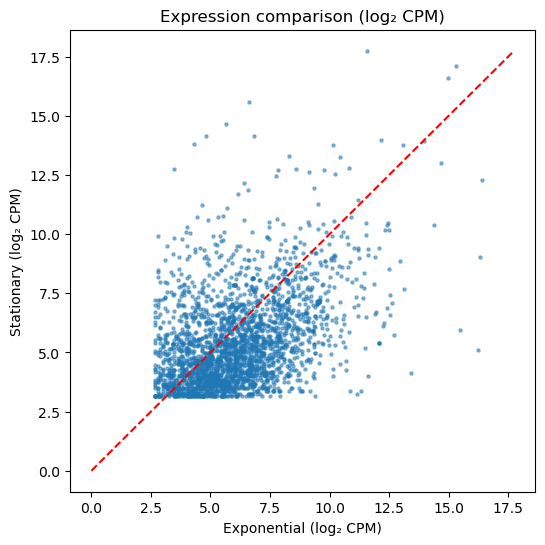

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(
    dataframe["log2_CPM_Exponential"],
    dataframe["log2_CPM_Stationary"],
    s=5,
    alpha=0.5
)

max_val = max(
    dataframe["log2_CPM_Exponential"].max(),
    dataframe["log2_CPM_Stationary"].max()
)

plt.plot([0, max_val], [0, max_val], "r--")
plt.xlabel("Exponential (log₂ CPM)")
plt.ylabel("Stationary (log₂ CPM)")
plt.title("Expression comparison (log₂ CPM)")
plt.show()

In [77]:
dataframe["log2FC_stationary_vs_exp"] = (
    dataframe["log2_CPM_Stationary"]
    - dataframe["log2_CPM_Exponential"]
)

dataframe

,Geneid,Chr,Start,End,Strand,Length,read_counts_Stationary,read_counts_Exponential,gene_name,locus_tag,CPM_Exponential,CPM_Stationary,log2_CPM_Exponential,log2_CPM_Stationary,log2FC_stationary_vs_exp
0,gene0,CU928145.2,203,268,+,66,444,506,thrL,EC55989_5066,272.405192,346.235006,8.094897,8.439769,0.344872
1,gene1,CU928145.2,349,2811,+,2463,17,78,thrA,EC55989_0002,41.991314,13.256746,5.425973,3.833573,-1.592401
2,gene2,CU928145.2,2813,3745,+,933,10,32,thrB,EC55989_0003,17.227206,7.798086,4.188022,3.137190,-1.050832
3,gene3,CU928145.2,3746,5032,+,1287,16,50,thrC,EC55989_0004,26.917509,12.476937,4.803098,3.752421,-1.050678
5,gene5,CU928145.2,5695,6471,-,777,11,115,yaaA,EC55989_0006,61.910271,8.577894,5.975224,3.259709,-2.715515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5136,gene5136,CU928145.2,5146441,5147310,-,870,256,346,rob,EC55989_5058,186.269163,199.630995,7.548970,7.648401,0.099431
5139,gene5139,CU928145.2,5148696,5150120,+,1425,22,45,creC,EC55989_5061,24.225758,17.155789,4.656826,4.182358,-0.474468
5140,gene5140,CU928145.2,5150178,5151530,+,1353,27,31,creD,EC55989_5062,16.688856,21.054831,4.144769,4.463023,0.318254
5141,gene5141,CU928145.2,5151590,5152306,-,717,1379,2837,arcA,EC55989_5063,1527.299469,1075.356022,10.577712,10.071940,-0.505772


In [78]:
dataframe["abs_log2FC"] = (
    dataframe["log2FC_stationary_vs_exp"].abs()
)

dataframe = dataframe.sort_values(
    "abs_log2FC",
    ascending=False
)

dataframe

,Geneid,Chr,Start,End,Strand,Length,read_counts_Stationary,read_counts_Exponential,gene_name,locus_tag,CPM_Exponential,CPM_Stationary,log2_CPM_Exponential,log2_CPM_Stationary,log2FC_stationary_vs_exp,abs_log2FC
799,gene799,CU928145.2,836617,837699,-,1083,43,144035,nmpC,EC55989_0782,77541.268579,33.531769,16.242695,5.109852,-11.132843,11.132843
994,gene994,CU928145.2,1048597,1049685,-,1089,78,85167,ompF,EC55989_0978,45849.670018,60.825069,15.484655,5.950120,-9.534535,9.534535
2216,gene2216,CU928145.2,2211026,2211253,+,228,18411,35,yodD,EC55989_2173,18.842256,14357.055630,4.310504,13.809573,9.499069,9.499069
4027,gene4027,CU928145.2,4023474,4024001,+,528,23113,50,gadE,EC55989_3955,26.917509,18023.715538,4.803098,14.137689,9.334591,9.334591
2928,gene2928,CU928145.2,2939302,2939685,-,384,21,20090,yfiD,EC55989_2868,10815.455172,16.375980,13.400940,4.119022,-9.281918,9.281918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2060,gene2060,CU928145.2,2077303,2077965,+,663,22,32,exoX,EC55989_2022,17.227206,17.155789,4.188022,4.182358,-0.005664,0.005664
1490,gene1490,CU928145.2,1499528,1500913,-,1386,11,16,puuP,EC55989_1458,8.613603,8.577894,3.265077,3.259709,-0.005369,0.005369
1583,gene1583,CU928145.2,1599977,1600040,-,64,11,16,rydC,EC55989_misc_RNA_33,8.613603,8.577894,3.265077,3.259709,-0.005369,0.005369
2227,gene2227,CU928145.2,2218425,2219120,-,696,18,26,yedJ,EC55989_2183,13.997105,14.036554,3.906612,3.910402,0.003790,0.003790


In [79]:
dataframe["mean_logCPM"] = dataframe[
    ["log2_CPM_Exponential", "log2_CPM_Stationary"]
].mean(axis=1)

In [81]:
dormancy_signature = dataframe.query(
    "abs_log2FC >= 2 and mean_logCPM >= 1"
)


In [82]:
dormancy_signature.shape

(903, 17)

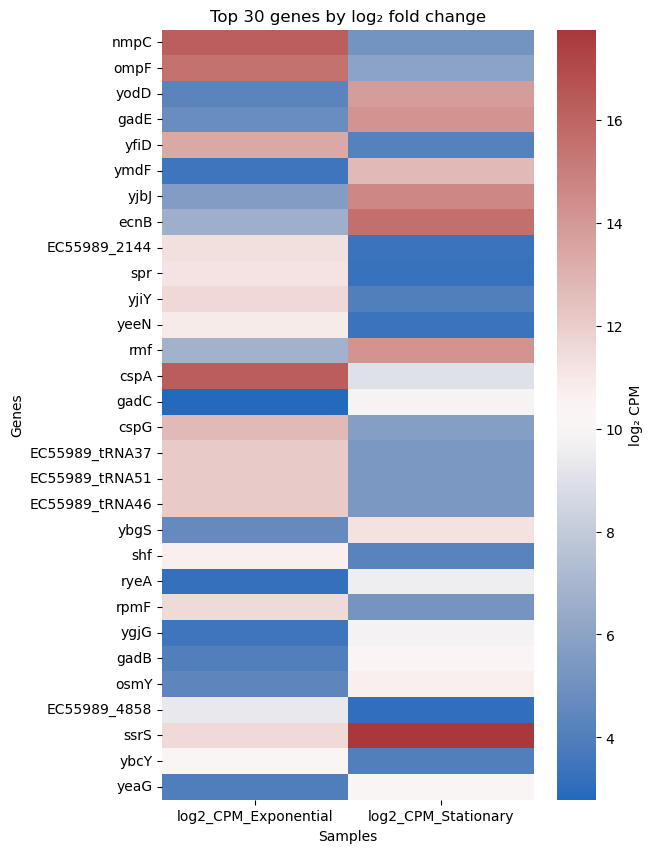

In [90]:
import seaborn as sns

top_genes = dataframe.sort_values("abs_log2FC", ascending=False).head(30)


heatmap_data = top_genes[["log2_CPM_Exponential", "log2_CPM_Stationary"]]

heatmap_data.index = top_genes["gene_name"]

plt.figure(figsize=(6,10))
sns.heatmap(
    heatmap_data,
    cmap="vlag",
    annot=False,  
    cbar_kws={"label": "log₂ CPM"}
)


plt.title("Top 30 genes by log₂ fold change")
plt.ylabel("Genes")
plt.xlabel("Samples")


plt.show()


In [94]:
dormancy_signature.head(30)

,Geneid,Chr,Start,End,Strand,Length,read_counts_Stationary,read_counts_Exponential,gene_name,locus_tag,CPM_Exponential,CPM_Stationary,log2_CPM_Exponential,log2_CPM_Stationary,log2FC_stationary_vs_exp,abs_log2FC,mean_logCPM
799,gene799,CU928145.2,836617,837699,-,1083,43,144035,nmpC,EC55989_0782,77541.268579,33.531769,16.242695,5.109852,-11.132843,11.132843,10.676274
994,gene994,CU928145.2,1048597,1049685,-,1089,78,85167,ompF,EC55989_0978,45849.670018,60.825069,15.484655,5.950120,-9.534535,9.534535,10.717388
2216,gene2216,CU928145.2,2211026,2211253,+,228,18411,35,yodD,EC55989_2173,18.842256,14357.055630,4.310504,13.809573,9.499069,9.499069,9.060038
4027,gene4027,CU928145.2,4023474,4024001,+,528,23113,50,gadE,EC55989_3955,26.917509,18023.715538,4.803098,14.137689,9.334591,9.334591,9.470394
2928,gene2928,CU928145.2,2939302,2939685,-,384,21,20090,yfiD,EC55989_2868,10815.455172,16.375980,13.400940,4.119022,-9.281918,9.281918,8.759981
1137,gene1137,CU928145.2,1176688,1176861,+,174,8941,19,ymdF,EC55989_1116,10.228653,6972.268448,3.489113,12.767619,9.278506,9.278506,8.128366
4613,gene4613,CU928145.2,4651096,4651305,+,210,32914,91,yjbJ,EC55989_4538,48.989867,25666.619358,5.643564,14.647662,9.004098,9.004098,10.145613
4779,gene4779,CU928145.2,4822120,4822266,+,147,63835,182,ecnB,EC55989_4704,97.979733,49779.080231,6.629061,15.603281,8.974220,8.974220,11.116171
2186,gene2186,CU928145.2,2187878,2188927,-,1050,12,4695,EC55989_2144,EC55989_2144,2527.554108,9.357703,11.304097,3.372632,-7.931465,7.931465,7.338365
2482,gene2482,CU928145.2,2485379,2485945,+,567,11,4241,spr,EC55989_2429,2283.143125,8.577894,11.157437,3.259709,-7.897729,7.897729,7.208573
